
=== index -STYLE frequency arrays (n starts at 0) ===
fVal0 = [  99.653043 ,  555.3234579, 1610.7313623, 3182.2915754, 5279.0518991,
 7900.1986042]
fVal1 = [  543.8082658,  1588.6081765,  3159.5313127,  5255.5168883,  7876.1650978,
 11021.307107 ]
fVal2 = [ 142.3183422,  936.5157353, 2240.782685 , 4071.8368419, 6428.5296199,
 9310.2662947]
fVal3 = [  330.3820863,  1407.8978528,  2973.2832751,  5064.8140651,  7682.2152091,
 10824.9305974]
fVal4 = [  579.9464163,  1953.3069397,  3782.9951355,  6136.2167846,  9014.8727127,
 12418.8251963]
fVal5 = [  889.6322781,  2569.8429427,  4667.5671805,  7284.1954654, 10425.0213614,
 14090.7414868]
fVal6 = [ 1258.3701526,  3255.4751782,  5625.1560046,  8507.2018274, 11911.3658522,
 15839.5868962]
fVal7 = [ 1685.3822282,  4008.6822751,  6654.2721368,  9803.9199891, 13472.7654628,
 17664.3727847]
fVal8 = [ 2170.084142 ,  4828.2718579,  7753.6831437, 11173.216661 , 15108.2085103,
 19564.2021315]
fVal9 = [ 2712.0212225,  5713.2784498,  8922.3495564, 126

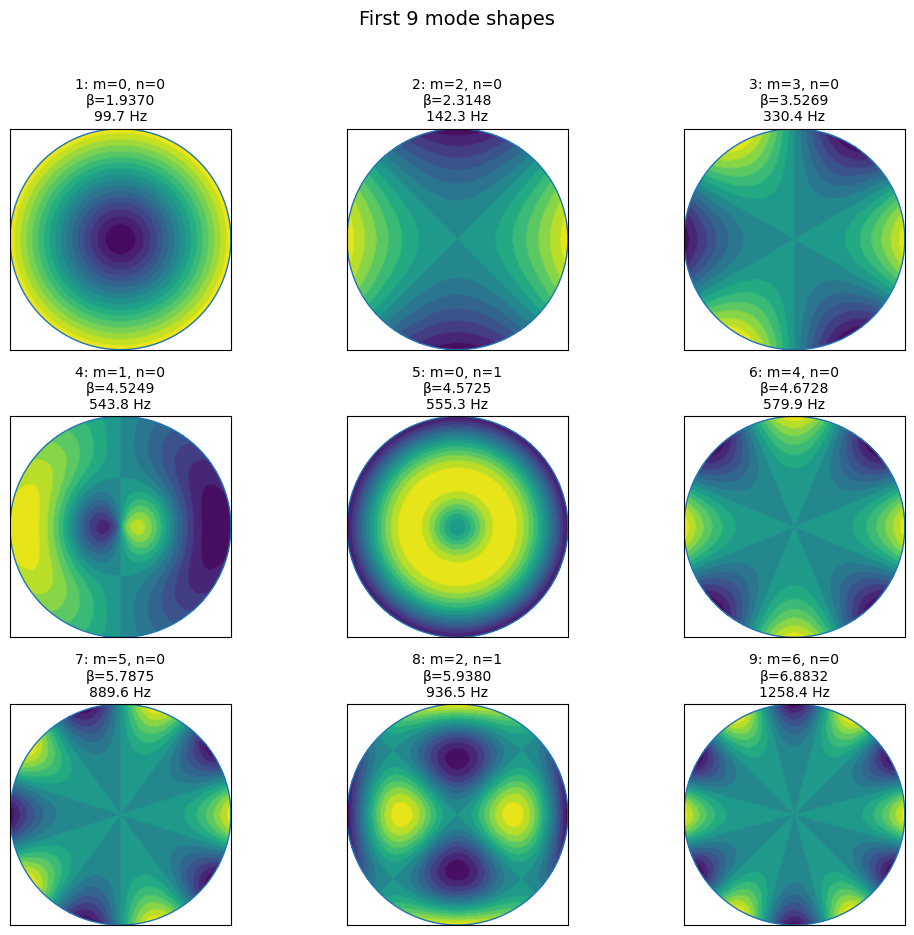

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.special as sp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

EPS_BETA = 1e-8
EPS_R = 1e-6


# ------------------------------------------------------------
# 
# ------------------------------------------------------------
def _basis_cols_and_derivs(x, m):
    """
    Returns (A, A1, A2, A3, B, B1, B2, B3) evaluated at x.
    Radial w(x) = cA*A(x) + cB*B(x)

    m>=2: A=Jm, B=Im
    m=0:  A=K0 + (pi/2)Y0, B=I0 - J0
    m=1:  A=-(K1 + (pi/2)Y1), B=I1 - J1   
    """
    x = np.asarray(x, dtype=float)

    if m==0:
        A = sp.kv(m, x) + (np.pi / 2.0) * sp.yv(m, x)
        A1 = sp.kvp(m, x, 1) + (np.pi / 2.0) * sp.yvp(m, x, 1)
        A2 = sp.kvp(m, x, 2) + (np.pi / 2.0) * sp.yvp(m, x, 2)
        A3 = sp.kvp(m, x, 3) + (np.pi / 2.0) * sp.yvp(m, x, 3)

        if m == 1:
           A, A1, A2, A3 = -A, -A1, -A2, -A3

        B = sp.iv(m, x) - sp.jv(m, x)
        B1 = sp.ivp(m, x, 1) - sp.jvp(m, x, 1)
        B2 = sp.ivp(m, x, 2) - sp.jvp(m, x, 2)
        B3 = sp.ivp(m, x, 3) - sp.jvp(m, x, 3)

    else:
        A = sp.jv(m, x)
        A1 = sp.jvp(m, x, 1)
        A2 = sp.jvp(m, x, 2)
        A3 = sp.jvp(m, x, 3)

        B = sp.iv(m, x)
        B1 = sp.ivp(m, x, 1)
        B2 = sp.ivp(m, x, 2)
        B3 = sp.ivp(m, x, 3)

    return A, A1, A2, A3, B, B1, B2, B3


# ------------------------------------------------------------
# Characteristic determinant (Mr=0, Vr=0 at r=a -> x=beta)
# ------------------------------------------------------------
def det_free_edge(beta, m, nu):
    beta = np.asarray(beta, dtype=float)
    out = np.full(beta.shape, np.nan, dtype=float)

    mask = beta > EPS_BETA
    if not np.any(mask):
        return float(out) if out.shape == () else out

    b = beta[mask]
    A, A1, A2, A3, B, B1, B2, B3 = _basis_cols_and_derivs(b, m)

    # Mr = 0: R'' + (nu/b)R' - (nu m^2 / b^2) R = 0
    a1 = A2 + (nu / b) * A1 - (nu * (m**2) / (b**2)) * A
    b1 = B2 + (nu / b) * B1 - (nu * (m**2) / (b**2)) * B

    # Vr = 0 (Kirchhoff effective shear, nu-dependent):
    # R''' + (1/b)R'' - ((1+(2-nu)m^2)/b^2)R' + ((3-nu)m^2/b^3)R = 0
    coef_d1 = (1.0 + (2.0 - nu) * (m**2)) / (b**2)
    coef_0 = ((3.0 - nu) * (m**2)) / (b**3)

    a2 = A3 + (1.0 / b) * A2 - coef_d1 * A1 + coef_0 * A
    b2 = B3 + (1.0 / b) * B2 - coef_d1 * B1 + coef_0 * B

    out[mask] = a1 * b2 - b1 * a2
    return float(out) if out.shape == () else out


def BA_ratio(beta, m, nu):
    """
    Return BA = cB/cA at the root beta using the numerically safer row.
    """
    beta = float(beta)
    if beta <= EPS_BETA:
        return np.nan

    # Rebuild rows at beta
    A, A1, A2, A3, B, B1, B2, B3 = _basis_cols_and_derivs(beta, m)

    a1 = A2 + (nu / beta) * A1 - (nu * (m**2) / (beta**2)) * A
    b1 = B2 + (nu / beta) * B1 - (nu * (m**2) / (beta**2)) * B

    coef_d1 = (1.0 + (2.0 - nu) * (m**2)) / (beta**2)
    coef_0 = ((3.0 - nu) * (m**2)) / (beta**3)
    a2 = A3 + (1.0 / beta) * A2 - coef_d1 * A1 + coef_0 * A
    b2 = B3 + (1.0 / beta) * B2 - coef_d1 * B1 + coef_0 * B

    # BA = -a/b; choose row with larger |b|
    if np.isfinite(b1) and np.isfinite(b2):
        if abs(b1) >= abs(b2) and abs(b1) > 0:
            return float(-a1 / b1)
        if abs(b2) > 0:
            return float(-a2 / b2)
    if np.isfinite(b1) and abs(b1) > 0:
        return float(-a1 / b1)
    if np.isfinite(b2) and abs(b2) > 0:
        return float(-a2 / b2)

    return np.nan


def find_roots_free_edge(m, nu, n_roots=6, x_min=1e-3, x_max=60.0, dx=1e-3):
    """
    Bracket roots by sign changes and refine with brentq.
    Returns first n_roots beta>0 roots.
    """
    xs = np.arange(x_min, x_max + dx, dx, dtype=float)
    fs = det_free_edge(xs, m, nu)
    fs = np.where(np.isfinite(fs), fs, np.nan)

    roots = []
    for i in range(len(xs) - 1):
        f1, f2 = fs[i], fs[i + 1]
        if np.isnan(f1) or np.isnan(f2):
            continue
        if f1 * f2 < 0:
            a, b = float(xs[i]), float(xs[i + 1])
            try:
                r = brentq(lambda x: float(det_free_edge(x, m, nu)), a, b, maxiter=300)
                if r > EPS_BETA and (len(roots) == 0 or abs(r - roots[-1]) > 1e-6):
                    roots.append(float(r))
                    if len(roots) >= n_roots:
                        break
            except Exception:
                pass

    return np.array(roots, dtype=float)


# ------------------------------------------------------------
# Frequency scaling (YOUR constants)
# ------------------------------------------------------------
def flexural_rigidity(E, h, nu):
    return E * h**3 / (12.0 * (1.0 - nu**2))


def beta_to_frequency_hz(beta, a, E, h, nu, rho):
    D = flexural_rigidity(E, h, nu)
    return (beta**2 / (2.0 * np.pi * a**2)) * np.sqrt(D / (rho * h))


# ------------------------------------------------------------
# index -style containers:
#   betaVal[m][n0]  with n0=0,1,2...
#   fVal[m][n0]
# ------------------------------------------------------------
def build_beta_and_freq_per_m(m_max, n_per_m, nu, a, E, h, rho, x_max=80.0, dx=1e-3):
    betaVal = {}
    fVal = {}

    for m in range(m_max + 1):
        betas = find_roots_free_edge(m, nu, n_roots=n_per_m, x_max=x_max, dx=dx)
        betas = betas[np.isfinite(betas) & (betas > EPS_BETA)]
        betaVal[m] = betas
        fVal[m] = np.array([beta_to_frequency_hz(b, a=a, E=E, h=h, nu=nu, rho=rho) for b in betas], dtype=float)

    return betaVal, fVal


def build_mode_list_global(betaVal, fVal, nu):
    """
    Build global list of modes with index  indexing n0 (0-based).
    Includes BA for plotting.
    """
    modes = []
    for m, betas in betaVal.items():
        for n0, beta in enumerate(betas):
            modes.append({
                "m": int(m),
                "n": int(n0),      # index  indexing
                "beta": float(beta),
                "BA": float(BA_ratio(beta, m, nu)),
                "f_Hz": float(fVal[m][n0]),
            })
    modes_sorted = sorted(modes, key=lambda d: d["f_Hz"])
    return modes_sorted


# ------------------------------------------------------------
# 2D mode shape plotting (first 9 global modes)
# ------------------------------------------------------------
def stabilized_basis_A_B(m, x):
    if m in (0, 1):
        A = sp.kv(m, x) + (np.pi / 2.0) * sp.yv(m, x)
        if m == 1:
            A = -A  # match eigenvalue sign convention
        B = sp.iv(m, x) - sp.jv(m, x)
    else:
        A = sp.jv(m, x)
        B = sp.iv(m, x)
    return A, B


def radial_shape_stable(r, beta, m, BA):
    r = np.asarray(r)
    r_eff = np.maximum(r, EPS_R) if m in (0, 1) else r
    x = beta * r_eff
    A, B = stabilized_basis_A_B(m, x)
    return A + BA * B


def mode_shape_2d(X, Y, beta, m, BA, phase="cos"):
    R = np.sqrt(X**2 + Y**2)
    TH = np.arctan2(Y, X)
    W = radial_shape_stable(R, beta, m, BA)
    ang = np.cos(m * TH) if (phase == "cos" or m == 0) else np.sin(m * TH)
    return W * ang


def normalize_inside_disk(Z, mask, eps=1e-12):
    Zm = np.where(mask, Z, np.nan)
    zmax = np.nanmax(np.abs(Zm))
    if (not np.isfinite(zmax)) or (zmax < eps):
        return Zm
    return Zm / zmax


def save_figure(fig, basepath_no_ext, dpi=300):
    fig.savefig(basepath_no_ext + ".pdf", bbox_inches="tight")
    fig.savefig(basepath_no_ext + ".png", dpi=dpi, bbox_inches="tight")


def plot_first9_mode_shapes(first9_modes, nu, OUTDIR="figures_mode_shapes", N=401, n_levels=16, phase_for_mgt0="cos"):
    xs = np.linspace(-1.0, 1.0, N)
    ys = np.linspace(-1.0, 1.0, N)
    X, Y = np.meshgrid(xs, ys)
    R = np.sqrt(X**2 + Y**2)
    mask = R <= 1.0

    fig, axes = plt.subplots(3, 3, figsize=(10.5, 9.5))
    axes = axes.flatten()

    for i, md in enumerate(first9_modes):
        ax = axes[i]
        m, n0, beta, BA, f = md["m"], md["n"], md["beta"], md["BA"], md["f_Hz"]

        Z = mode_shape_2d(X, Y, beta, m, BA, phase=phase_for_mgt0)
        Z = normalize_inside_disk(Z, mask)

        ax.contourf(X, Y, Z, levels=n_levels)
        ax.contour(X, Y, Z, levels=n_levels, linewidths=0.6)

        th = np.linspace(0, 2 * np.pi, 600)
        ax.plot(np.cos(th), np.sin(th), linewidth=1.0)

        ax.set_aspect("equal", "box")
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{i+1}: m={m}, n={n0}\nβ={beta:.4f}\n{f:.1f} Hz", fontsize=10)

    fig.suptitle(fr"First 9 mode shapes", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    os.makedirs(OUTDIR, exist_ok=True)
    base = os.path.join(OUTDIR, "modes_2d_contours_first9")
    save_figure(fig, base)
    plt.show()


# ------------------------------------------------------------
# MAIN (set YOUR constants here)
# ------------------------------------------------------------
if __name__ == "__main__":

    # -------- YOUR material/geometry constants --------
    a = 0.1225        # radius [m]
    h = 0.0016        # thickness [m]
    E = 2.1e11        # Young's modulus [Pa]
    nu = 0.3          # YOUR Poisson ratio
    rho = 7850.0      # density [kg/m^3]

    # -------- computation controls --------
    m_max = 10
    n_per_m = 6
    x_max = 80.0
    dx = 1e-3

    # Build per-m arrays like index essor
    betaVal, fVal = build_beta_and_freq_per_m(
        m_max=m_max, n_per_m=n_per_m, nu=nu, a=a, E=E, h=h, rho=rho, x_max=x_max, dx=dx
    )

    # Print like index essor: fVal0, fVal1, ...
    print("\n=== index -STYLE frequency arrays (n starts at 0) ===")
    for m in range(m_max + 1):
        arr = fVal[m]
        print(f"fVal{m} = {np.array2string(arr, precision=7, separator=', ')}")

    # Global list and first 9 modes (sorted by frequency)
    modes_sorted = build_mode_list_global(betaVal, fVal, nu=nu)
    first9 = modes_sorted[:9]

    print("\n=== First 9 modes (global ordering), index  indexing ===")
    df9 = pd.DataFrame(
        [{"mode#": i + 1, "m": md["m"], "n": md["n"], "beta": md["beta"], "f_Hz": md["f_Hz"]} for i, md in enumerate(first9)]
    ).set_index("mode#")
    with pd.option_context("display.precision", 6):
        print(df9)

    # Plot 2D mode shapes for the first 9 modes
    OUTDIR = "figures_mode_shapes"
    plot_first9_mode_shapes(first9, nu=nu, OUTDIR=OUTDIR, N=401, n_levels=16, phase_for_mgt0="cos")


In [13]:
import numpy as np
import pandas as pd

def beta_table(betaVal, m_max=None, n_max=None, precision=6):
    """
    Build a table of beta values with rows = m and columns = n (0-based).
    betaVal: dict {m: array_like of betas}, where betas[n] is the n-th root for that m.
    m_max: maximum m to include (defaults to max(betaVal.keys()))
    n_max: maximum n to include (defaults to max length across m) -> columns 0..n_max-1
    """
    if m_max is None:
        m_max = int(max(betaVal.keys()))
    if n_max is None:
        n_max = int(max(len(v) for v in betaVal.values()))

    cols = [f"n={n}" for n in range(n_max)]
    idx  = [f"m={m}" for m in range(m_max + 1)]
    T = pd.DataFrame(np.nan, index=idx, columns=cols, dtype=float)

    for m in range(m_max + 1):
        betas = np.asarray(betaVal.get(m, []), dtype=float)
        for n in range(min(n_max, len(betas))):
            T.loc[f"m={m}", f"n={n}"] = betas[n]

    # round for display (keeps underlying floats if you need them)
    return T.round(precision)

# ---- Example usage (after you computed betaVal) ----
# betaVal, fVal = build_beta_and_freq_per_m(...)

Tbeta = beta_table(betaVal, m_max=m_max, n_max=n_per_m, precision=6)

print("\n=== Beta table β(m,n) (n starts at 0) ===")
with pd.option_context("display.width", 140, "display.max_columns", None):
    print(Tbeta)

# Optional: save
Tbeta.to_csv("beta_table_m0_to_mmax.csv", index=True)
print("\nSaved: beta_table_m0_to_mmax.csv")



=== Beta table β(m,n) (n starts at 0) ===
            n=0        n=1        n=2        n=3        n=4        n=5
m=0    1.937000   4.572538   7.787460  10.945970  14.098154  17.246592
m=1    4.524881   7.733795  10.906756  14.066693  17.220339  20.370460
m=2    2.314807   5.938022   9.185106  12.381677  15.557511  18.722564
m=3    3.526895   7.280645  10.580408  13.809121  17.006992  20.188165
m=4    4.672811   8.575699  11.934444  15.199686  18.423158  21.623428
m=5    5.787481   9.836432  13.256521  16.560562  19.811746  23.033037
m=6    6.883170  11.071118  14.552968  17.896893  21.177031  24.420593
m=7    7.965875  12.285281  15.828310  19.212512  22.522296  25.788934
m=8    9.039045  13.482801  17.085918  20.510365  23.850131  27.140344
m=9   10.104872  14.666517  18.328372  21.792773  25.162620  28.476694
m=10  11.164844  15.838569  19.557705  23.061603  26.461468  29.799539

Saved: beta_table_m0_to_mmax.csv


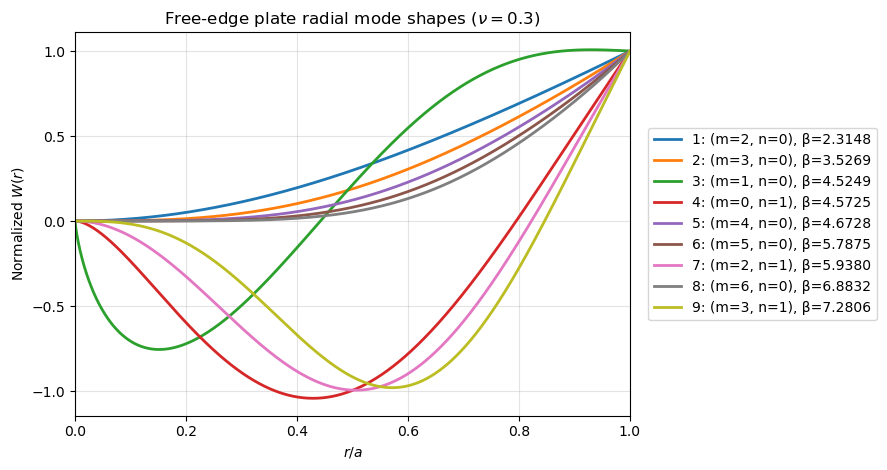

1 2 0 2.3148066415793593
2 3 0 3.5268949751031897
3 1 0 4.5248812265006615
4 0 1 4.572537662226385
5 4 0 4.6728110066821
6 5 0 5.787480590681152
7 2 1 5.938022256220781
8 6 0 6.8831698435096165
9 3 1 7.280644988542118


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def get_first9_modes_by_beta(betaVal, nu, exclude={(0, 0)}, n_modes=9):
    """
  
    """
    modes = []
    for m, betas in betaVal.items():
        for n0, beta in enumerate(betas):
            if (m, n0) in exclude:
                continue
            modes.append({
                "m": int(m),
                "n": int(n0),          # index  indexing
                "beta": float(beta),
                "BA": float(BA_ratio(beta, m, nu)),
            })
    modes = sorted(modes, key=lambda d: d["beta"])
    return modes[:n_modes]


def plot_radial_mode_shapes_first9(betaVal, nu, exclude={(0, 0)}, n_modes=9,
                                   Nr=1200, normalize="edge", title=None,
                                   figsize=(9.0, 4.8), grid=True):
    """
    Plots normalized radial shapes R_{m,n}(r) for the first n_modes modes (by beta).

    normalize:
      - "edge": enforce R(1)=1 (like your old figure: all curves meet at 1 at r/a=1)
      - "max":  normalize by max(|R|) on [0,1]
    """
    first9 = get_first9_modes_by_beta(betaVal, nu, exclude=exclude, n_modes=n_modes)

    r = np.linspace(0.0, 1.0, Nr)  # r/a in [0,1]
    fig = plt.figure(figsize=figsize)

    for i, md in enumerate(first9, start=1):
        m, n0, beta, BA = md["m"], md["n"], md["beta"], md["BA"]

        # radial shape from EDIT3 (stabilized for m=0,1)
        W = radial_shape_stable(r, beta, m, BA)

        # Normalize
        if normalize == "edge":
            edge = W[-1]
            if np.isfinite(edge) and abs(edge) > 1e-14:
                Wn = W / edge
            else:
                mx = np.nanmax(np.abs(W))
                Wn = W / mx if (np.isfinite(mx) and mx > 1e-14) else W
        elif normalize == "max":
            mx = np.nanmax(np.abs(W))
            Wn = W / mx if (np.isfinite(mx) and mx > 1e-14) else W
        else:
            Wn = W

        plt.plot(r, Wn, linewidth=2.0,
                 label=f"{i}: (m={m}, n={n0}), β={beta:.4f}")

    plt.xlabel(r"$r/a$")
    plt.ylabel(r"Normalized $W(r)$")
    if title is None:
        title = rf"Free-edge plate radial mode shapes ($\nu={nu}$)"
    plt.title(title)

    if grid:
        plt.grid(True, alpha=0.35)

    plt.xlim(0, 1)
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    plt.tight_layout()
    plt.show()

    return first9


# ------------------ USAGE (after you computed betaVal, fVal in EDIT3) ------------------
# betaVal, fVal = build_beta_and_freq_per_m(...)

# Plot the NEW first 9 modes (excluding (m,n)=(0,0) as you requested)
first9_modes = plot_radial_mode_shapes_first9(
    betaVal=betaVal,
    nu=nu,
    exclude={(0, 0)},     # don't count the (0,0) mode
    n_modes=9,
    Nr=1500,
    normalize="edge"      # matches your old plot style (all curves meet at 1 at r/a=1)
)

# If you also want to print the list it used:
for i, md in enumerate(first9_modes, start=1):
    print(i, md["m"], md["n"], md["beta"])


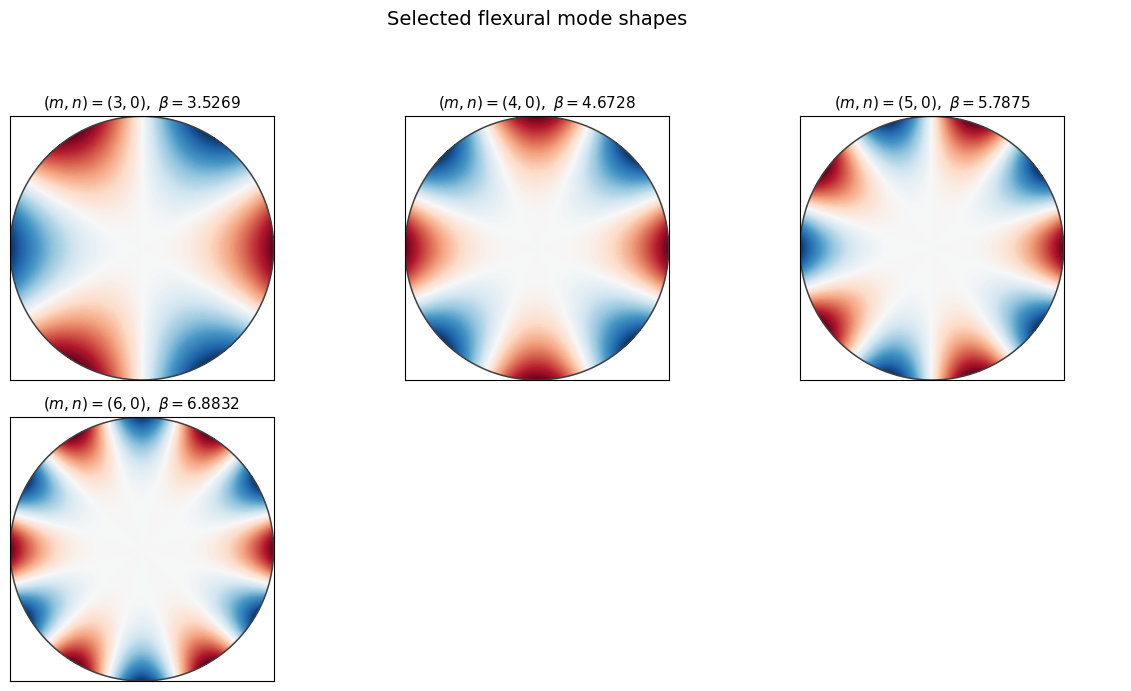

Saved: modes_(1,0)_(3,0)_(4,0)_(5,0)_(6,0)_EDIT3.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp

# ============================================================
# Plot selected flexural mode shapes using EDIT3 data
# index INDEXING: n = 0,1,2,...
# Uses:
#  - EDIT3 stabilized basis (correct sign for m=1)
#  - Kirchhoff effective shear (nu-dependent) for BA ratio
#  - betaVal directly (no DataFrames)
# ============================================================

# ---- Settings ----
nu = 0.3
N = 501
n_levels = 200
EPS_R = 1e-6
cmap = "RdBu_r"

# ---- Modes to plot (index indexing) ----
modes_to_plot = [
    (3, 0),
    (4, 0),
    (5, 0),
    (6, 0),
]

# ----------------------------
# EDIT3-native beta getter
# ----------------------------
def get_beta_from_betaVal(betaVal, m, n):
    try:
        return float(betaVal[int(m)][int(n)])
    except KeyError:
        raise KeyError(f"m={m} not found in betaVal")
    except IndexError:
        raise IndexError(f"n={n} not available for m={m}")

# ----------------------------
# Stabilized basis (EDIT3 sign convention)
# ----------------------------
def stabilized_basis_A_B(m, x):
    if m in (0, 1):
        A = sp.kv(m, x) + (np.pi / 2.0) * sp.yv(m, x)
        if m == 1:
            A = -A
        B = sp.iv(m, x) - sp.jv(m, x)
    else:
        A = sp.jv(m, x)
        B = sp.iv(m, x)
    return A, B

def radial_shape_stable(r, beta, m, BA):
    r = np.asarray(r)
    r_eff = np.maximum(r, EPS_R) if m in (0, 1) else r
    x = beta * r_eff
    A, B = stabilized_basis_A_B(m, x)
    return A + BA * B

def mode_shape_2d(X, Y, beta, m, BA, phase="cos"):
    R = np.sqrt(X**2 + Y**2)
    TH = np.arctan2(Y, X)
    W = radial_shape_stable(R, beta, m, BA)
    ang = np.cos(m * TH) if (phase == "cos" or m == 0) else np.sin(m * TH)
    return W * ang

def normalize_inside_disk(Z, mask, eps=1e-12):
    Zm = np.where(mask, Z, np.nan)
    zmax = np.nanmax(np.abs(Zm))
    if not np.isfinite(zmax) or zmax < eps:
        return Zm
    return Zm / zmax

# ----------------------------
# BA ratio (EDIT3: Kirchhoff effective shear)
# ----------------------------
def _basis_cols_and_derivs(x, m):
    x = np.asarray(x, dtype=float)

    if m in (0, 1):
        A = sp.kv(m, x) + (np.pi / 2.0) * sp.yv(m, x)
        A1 = sp.kvp(m, x, 1) + (np.pi / 2.0) * sp.yvp(m, x, 1)
        A2 = sp.kvp(m, x, 2) + (np.pi / 2.0) * sp.yvp(m, x, 2)
        A3 = sp.kvp(m, x, 3) + (np.pi / 2.0) * sp.yvp(m, x, 3)
        if m == 1:
            A, A1, A2, A3 = -A, -A1, -A2, -A3
        B = sp.iv(m, x) - sp.jv(m, x)
        B1 = sp.ivp(m, x, 1) - sp.jvp(m, x, 1)
        B2 = sp.ivp(m, x, 2) - sp.jvp(m, x, 2)
        B3 = sp.ivp(m, x, 3) - sp.jvp(m, x, 3)
    else:
        A = sp.jv(m, x)
        A1 = sp.jvp(m, x, 1)
        A2 = sp.jvp(m, x, 2)
        A3 = sp.jvp(m, x, 3)
        B = sp.iv(m, x)
        B1 = sp.ivp(m, x, 1)
        B2 = sp.ivp(m, x, 2)
        B3 = sp.ivp(m, x, 3)

    return A, A1, A2, A3, B, B1, B2, B3

def BA_ratio_free_edge(beta, m, nu):
    beta = float(beta)
    if beta <= 0 or not np.isfinite(beta):
        return np.nan

    A, A1, A2, A3, B, B1, B2, B3 = _basis_cols_and_derivs(beta, m)

    # Mr = 0
    a1 = A2 + (nu / beta) * A1 - (nu * m**2 / beta**2) * A
    b1 = B2 + (nu / beta) * B1 - (nu * m**2 / beta**2) * B

    # Vr = 0 (Kirchhoff effective shear)
    coef_d1 = (1.0 + (2.0 - nu) * m**2) / beta**2
    coef_0 = ((3.0 - nu) * m**2) / beta**3
    a2 = A3 + (1.0 / beta) * A2 - coef_d1 * A1 + coef_0 * A
    b2 = B3 + (1.0 / beta) * B2 - coef_d1 * B1 + coef_0 * B

    if abs(b1) >= abs(b2) and abs(b1) > 0:
        return -a1 / b1
    if abs(b2) > 0:
        return -a2 / b2
    return np.nan

# ----------------------------
# Plot
# ----------------------------
def plot_selected_modes(modes, betaVal, savepath, phase="cos"):
    # grid
    xs = np.linspace(-1.0, 1.0, N)
    ys = np.linspace(-1.0, 1.0, N)
    X, Y = np.meshgrid(xs, ys)
    R = np.sqrt(X**2 + Y**2)
    mask = R <= 1.0

    # layout: 2x3 fits 5 plots nicely (last panel unused)
    n_modes = len(modes)
    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(12.0, 7.0))
    axes = np.ravel(axes)

    # draw each requested mode
    for i, (m, n) in enumerate(modes):
        ax = axes[i]
        beta = get_beta_from_betaVal(betaVal, m, n)
        BA = BA_ratio_free_edge(beta, m, nu)

        Z = mode_shape_2d(X, Y, beta, m, BA, phase=phase)
        Z = normalize_inside_disk(Z, mask)

        ax.contourf(X, Y, Z, levels=n_levels, cmap=cmap)
        th = np.linspace(0, 2*np.pi, 600)
        ax.plot(np.cos(th), np.sin(th), color="0.25", linewidth=1.1)

        ax.set_aspect("equal", "box")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(fr"$(m,n)=({m},{n}),\ \beta={beta:.4f}$", fontsize=11)

    # hide any unused axes
    for j in range(n_modes, nrows * ncols):
        axes[j].axis("off")

    fig.suptitle("Selected flexural mode shapes", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", savepath)

# ---- Run ----
# NOTE: betaVal must already exist in your namespace (from EDIT3).
plot_selected_modes(
    modes_to_plot,
    betaVal,
    savepath="modes_(1,0)_(3,0)_(4,0)_(5,0)_(6,0)_EDIT3.png",
    phase="cos",
)


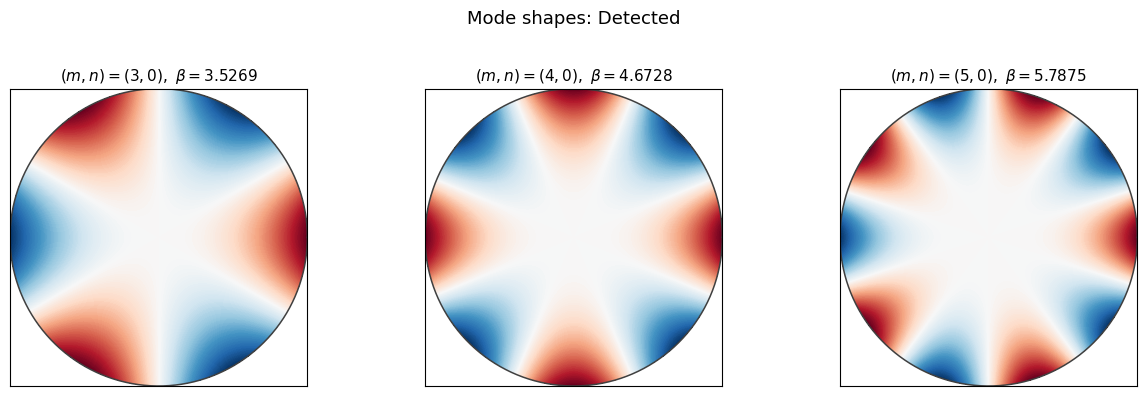

Saved: modes_(3,0)_(4,0)_(5,0)_row.png


In [5]:
# ============================================================
# NEXT CELL: plot only m = 3,4,5 (with n=0) in a single row
# index  indexing, EDIT3-consistent. Assumes betaVal is already built.
# ============================================================

modes_m345 = [(3, 0), (4, 0), (5, 0)]  # (m,n) = (3,0), (4,0), (5,0)

def plot_modes_row(modes, betaVal, nu, N=501, n_levels=200, cmap="RdBu_r",
                   phase="cos", savepath="modes_m3_m4_m5_row.png"):
    xs = np.linspace(-1.0, 1.0, N)
    ys = np.linspace(-1.0, 1.0, N)
    X, Y = np.meshgrid(xs, ys)
    R = np.sqrt(X**2 + Y**2)
    mask = R <= 1.0

    fig, axes = plt.subplots(1, len(modes), figsize=(4.2 * len(modes), 3.8))
    if len(modes) == 1:
        axes = [axes]

    for ax, (m, n) in zip(axes, modes):
        beta = get_beta_from_betaVal(betaVal, m, n)
        BA = BA_ratio_free_edge(beta, m, nu)

        Z = mode_shape_2d(X, Y, beta, m, BA, phase=phase)
        Z = normalize_inside_disk(Z, mask)

        ax.contourf(X, Y, Z, levels=n_levels, cmap=cmap)
        th = np.linspace(0, 2*np.pi, 600)
        ax.plot(np.cos(th), np.sin(th), color="0.25", linewidth=1.1)

        ax.set_aspect("equal", "box")
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(fr"$(m,n)=({m},{n}),\ \beta={beta:.4f}$", fontsize=11)

    fig.suptitle("Mode shapes: Detected", fontsize=13, y=1.03)
    plt.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", savepath)

# ---- Run ----
plot_modes_row(modes_m345, betaVal, nu=nu, savepath="modes_(3,0)_(4,0)_(5,0)_row.png")


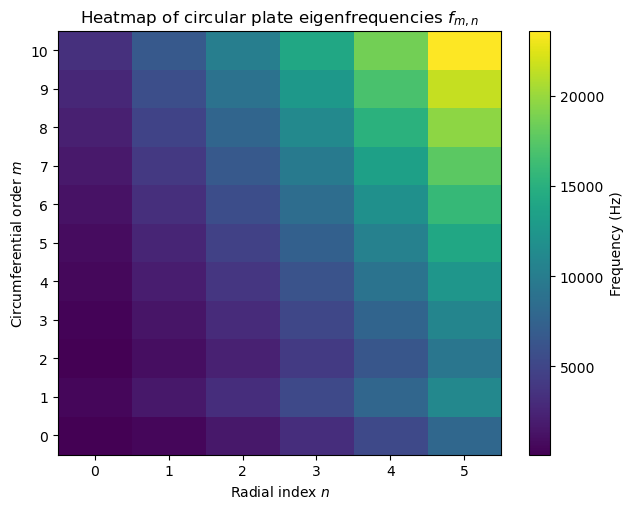

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# DETERMINE SIZES FROM EDIT3
# ----------------------------
m_max = len(fVal) - 1
n_max = max(len(fVal[m]) for m in range(len(fVal))) - 1

# ----------------------------
# BUILD FREQUENCY ARRAY
# ----------------------------
freq = np.full((m_max + 1, n_max + 1), np.nan)

for m in range(m_max + 1):
    for n in range(len(fVal[m])):
        freq[m, n] = fVal[m][n]

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(6.5, 5.2))
im = plt.imshow(
    freq,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(im, label="Frequency (Hz)")
plt.xlabel("Radial index $n$")
plt.ylabel("Circumferential order $m$")
plt.title("Heatmap of circular plate eigenfrequencies $f_{m,n}$")

plt.xticks(range(n_max + 1))
plt.yticks(range(m_max + 1))

plt.tight_layout()
plt.show()


Max symmetry error: 0.0


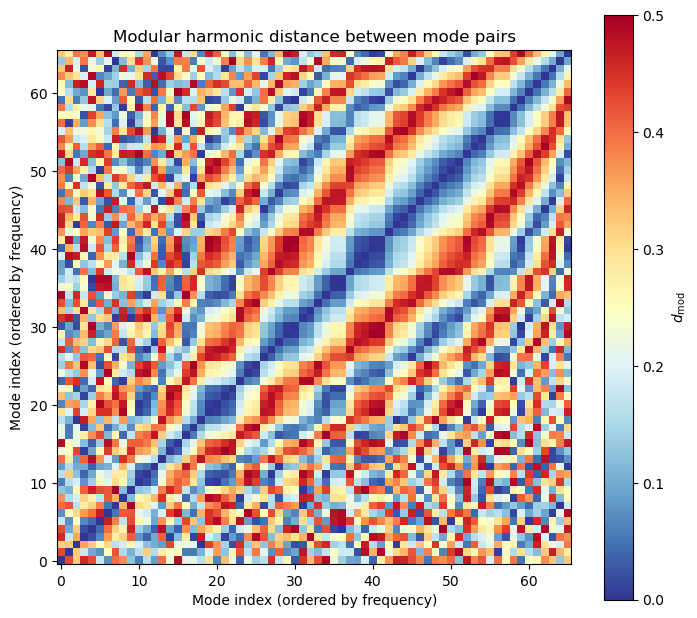

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# COLLECT MODES FROM EDIT3
# ----------------------------
modes = []
freqs = []

for m in range(len(fVal)):
    for n in range(len(fVal[m])):
        f = float(fVal[m][n])
        if f > 0:   # skip rigid body if it exists
            modes.append((m, n))
            freqs.append(f)

freqs = np.array(freqs)
N = len(freqs)

# ----------------------------
# MODULAR HARMONIC DISTANCE (CORRECT: uses f_low=min, f_high=max)
# ----------------------------
dmod = np.zeros((N, N), dtype=float)

for i in range(N):
    for j in range(N):
        fi = freqs[i]
        fj = freqs[j]
        f_low  = fi if fi <= fj else fj
        f_high = fj if fi <= fj else fi

        r = np.mod(f_high, f_low)
        dmod[i, j] = min(r, f_low - r) / f_low

# ----------------------------
# SORT BY FREQUENCY
# ----------------------------
order = np.argsort(freqs)
freqs_sorted = freqs[order]
modes_sorted = [modes[i] for i in order]
dmod_sorted = dmod[np.ix_(order, order)]

# ----------------------------
# SANITY CHECK: SHOULD BE SYMMETRIC
# ----------------------------
sym_err = np.max(np.abs(dmod_sorted - dmod_sorted.T))
print("Max symmetry error:", sym_err)

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(7.2, 6.4))
im = plt.imshow(
    dmod_sorted,
    origin="lower",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=0.5
)
plt.colorbar(im, label=r"$d_{\mathrm{mod}}$")
plt.xlabel("Mode index (ordered by frequency)")
plt.ylabel("Mode index (ordered by frequency)")
plt.title("Modular harmonic distance between mode pairs")

plt.tight_layout()
plt.show()


In [8]:
import numpy as np

# ---- collect modes + freqs (same as your plotting cell) ----
modes = []
freqs = []
for m in range(len(fVal)):
    for n in range(len(fVal[m])):
        f = float(fVal[m][n])
        if f > 0:
            modes.append((m, n))
            freqs.append(f)

freqs = np.array(freqs)
order = np.argsort(freqs)
freqs = freqs[order]
modes = [modes[i] for i in order]

def dmod_pair(f1, f2):
    f_low, f_high = (f1, f2) if f1 <= f2 else (f2, f1)
    r = np.mod(f_high, f_low)
    return min(r, f_low - r) / f_low

# ---- find near-integer ratios ----
thr = 0.01  # adjust if you want (0.005 stricter, 0.02 looser)
pairs = []
N = len(freqs)

for i in range(N):
    for j in range(i+1, N):
        f1, f2 = freqs[i], freqs[j]
        f_low, f_high = (f1, f2) if f1 <= f2 else (f2, f1)
        ratio = f_high / f_low
        p = int(np.round(ratio))  # nearest integer multiple
        if p < 2:
            continue
        d = dmod_pair(f_low, f_high)
        if d <= thr:
            pairs.append((d, p, i, j, f_low, f_high))

pairs.sort(key=lambda x: x[0])

print(f"Total modes used: {N}")
print(f"Near-harmonic threshold d_mod <= {thr}")
print(f"Number of near-harmonic pairs found: {len(pairs)}")
print("\nTop 15 near-harmonic pairs (smallest d_mod):")
for row in pairs[:15]:
    d, p, i, j, f_low, f_high = row
    (m1,n1) = modes[i]
    (m2,n2) = modes[j]
    print(f"d={d:.5f}  ~{p}:1   "
          f"({m1},{n1}) {f_low:.3f} Hz  <->  ({m2},{n2}) {f_high:.3f} Hz")


Total modes used: 66
Near-harmonic threshold d_mod <= 0.01
Number of near-harmonic pairs found: 34

Top 15 near-harmonic pairs (smallest d_mod):
d=0.00046  ~3:1   (0,4) 5279.052 Hz  <->  (6,5) 15839.587 Hz
d=0.00047  ~9:1   (3,0) 330.382 Hz  <->  (3,2) 2973.283 Hz
d=0.00084  ~3:1   (3,2) 2973.283 Hz  <->  (9,2) 8922.350 Hz
d=0.00171  ~23:1   (2,1) 936.516 Hz  <->  (9,5) 21538.258 Hz
d=0.00177  ~12:1   (0,1) 555.323 Hz  <->  (10,1) 6662.901 Hz
d=0.00244  ~3:1   (0,2) 1610.731 Hz  <->  (8,1) 4828.272 Hz
d=0.00245  ~2:1   (2,5) 9310.266 Hz  <->  (10,4) 18597.703 Hz
d=0.00285  ~29:1   (4,0) 579.946 Hz  <->  (9,4) 16816.792 Hz
d=0.00319  ~2:1   (1,1) 1588.608 Hz  <->  (0,3) 3182.292 Hz
d=0.00401  ~19:1   (4,0) 579.946 Hz  <->  (1,5) 11021.307 Hz
d=0.00445  ~2:1   (7,3) 9803.920 Hz  <->  (8,5) 19564.202 Hz
d=0.00457  ~4:1   (3,1) 1407.898 Hz  <->  (6,2) 5625.156 Hz
d=0.00496  ~2:1   (0,5) 7900.199 Hz  <->  (6,5) 15839.587 Hz
d=0.00514  ~3:1   (7,0) 1685.382 Hz  <->  (3,3) 5064.814 Hz
d=0.005

In [9]:
import numpy as np

# modes + freqs already built above; if not, re-run the collect block first

# global smallest spacings
df = np.diff(freqs)
idx = np.argsort(df)

print("Smallest 10 frequency spacings (global):")
for k in idx[:10]:
    (m1,n1) = modes[k]
    (m2,n2) = modes[k+1]
    print(f"Δf={df[k]:.3f} Hz between ({m1},{n1}) {freqs[k]:.3f} Hz "
          f"and ({m2},{n2}) {freqs[k+1]:.3f} Hz")

# in a measurement band (edit if needed)
fmin, fmax = 200.0, 1600.0
mask = (freqs >= fmin) & (freqs <= fmax)
freq_band = freqs[mask]
modes_band = [modes[i] for i in range(len(freqs)) if mask[i]]

if len(freq_band) >= 2:
    dfb = np.diff(freq_band)
    kb = int(np.argmin(dfb))
    (ma,na) = modes_band[kb]
    (mb,nb) = modes_band[kb+1]
    print(f"\nWithin {fmin:.0f}–{fmax:.0f} Hz band:")
    print(f"Smallest spacing: Δf={dfb[kb]:.3f} Hz between "
          f"({ma},{na}) {freq_band[kb]:.3f} Hz and ({mb},{nb}) {freq_band[kb+1]:.3f} Hz")
else:
    print(f"\nWithin {fmin:.0f}–{fmax:.0f} Hz band: fewer than 2 modes found.")


Smallest 10 frequency spacings (global):
Δf=8.629 Hz between (7,2) 6654.272 Hz and (10,1) 6662.901 Hz
Δf=11.515 Hz between (1,0) 543.808 Hz and (0,1) 555.323 Hz
Δf=22.123 Hz between (1,1) 1588.608 Hz and (0,2) 1610.731 Hz
Δf=22.760 Hz between (1,2) 3159.531 Hz and (0,3) 3182.292 Hz
Δf=23.535 Hz between (1,3) 5255.517 Hz and (0,4) 5279.052 Hz
Δf=24.034 Hz between (1,4) 7876.165 Hz and (0,5) 7900.199 Hz
Δf=24.623 Hz between (0,1) 555.323 Hz and (4,0) 579.946 Hz
Δf=34.973 Hz between (5,5) 14090.741 Hz and (10,3) 14125.715 Hz
Δf=42.665 Hz between (0,0) 99.653 Hz and (2,0) 142.318 Hz
Δf=46.883 Hz between (5,0) 889.632 Hz and (2,1) 936.516 Hz

Within 200–1600 Hz band:
Smallest spacing: Δf=11.515 Hz between (1,0) 543.808 Hz and (0,1) 555.323 Hz


Total modes used: 66
Global adjacent min spacing: 8.629 Hz
Mean adjacent spacing: 361.325 Hz
Median adjacent spacing: 225.743 Hz
Band (200-1600 Hz) adjacent min spacing: 11.515 Hz


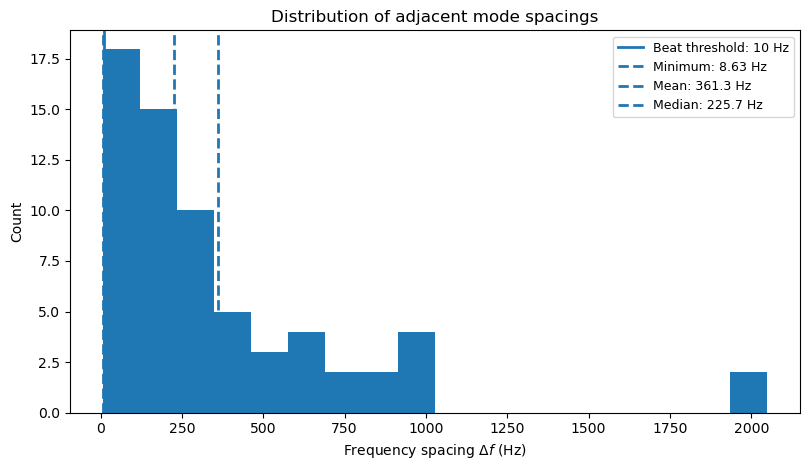

Saved: mode_spacing_hist_EDIT3.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Collect and sort all positive frequencies
# ----------------------------
modes = []
freqs = []

for m in range(len(fVal)):
    for n in range(len(fVal[m])):
        f = float(fVal[m][n])
        if f > 0:  # skip rigid-body if present
            modes.append((m, n))
            freqs.append(f)

freqs = np.array(freqs)
order = np.argsort(freqs)
freqs_sorted = freqs[order]
modes_sorted = [modes[i] for i in order]

# ----------------------------
# Adjacent spacings (sorted-by-frequency neighbours)
# ----------------------------
df = np.diff(freqs_sorted)

df_min = float(np.min(df))
df_mean = float(np.mean(df))
df_median = float(np.median(df))

# Optional: minimum spacing within measurement band
fmin_band, fmax_band = 200.0, 1600.0
mask = (freqs_sorted >= fmin_band) & (freqs_sorted <= fmax_band)
freq_band = freqs_sorted[mask]
df_band_min = float(np.min(np.diff(freq_band))) if len(freq_band) >= 2 else np.nan

print(f"Total modes used: {len(freqs_sorted)}")
print(f"Global adjacent min spacing: {df_min:.3f} Hz")
print(f"Mean adjacent spacing: {df_mean:.3f} Hz")
print(f"Median adjacent spacing: {df_median:.3f} Hz")
print(f"Band ({fmin_band:.0f}-{fmax_band:.0f} Hz) adjacent min spacing: {df_band_min:.3f} Hz")

# ----------------------------
# Plot histogram
# ----------------------------
plt.figure(figsize=(8.2, 4.8))
plt.hist(df, bins=18)  # adjust bins if you want

# Beat threshold
plt.axvline(10.0, linewidth=2, label="Beat threshold: 10 Hz")

# Stats lines (all correct from THIS run)
plt.axvline(df_min, linestyle="--", linewidth=2, label=f"Minimum: {df_min:.2f} Hz")
plt.axvline(df_mean, linestyle="--", linewidth=2, label=f"Mean: {df_mean:.1f} Hz")
plt.axvline(df_median, linestyle="--", linewidth=2, label=f"Median: {df_median:.1f} Hz")

plt.title("Distribution of adjacent mode spacings")
plt.xlabel(r"Frequency spacing $\Delta f$ (Hz)")
plt.ylabel("Count")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()

# Save if you want
plt.savefig("mode_spacing_hist_EDIT3.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: mode_spacing_hist_EDIT3.png")


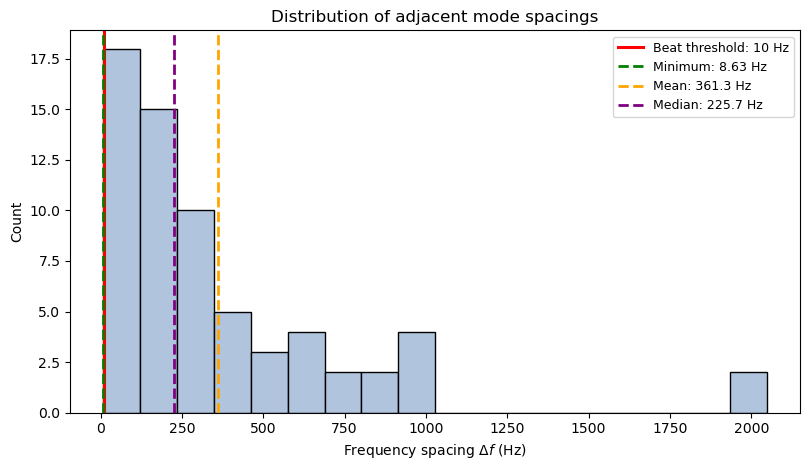

In [11]:
# ----------------------------
# Plot histogram (with distinct colors)
# ----------------------------
plt.figure(figsize=(8.2, 4.8))
plt.hist(df, bins=18, color="lightsteelblue", edgecolor="black")

# Beat threshold
plt.axvline(
    10.0,
    color="red",
    linewidth=2.2,
    linestyle="-",
    label="Beat threshold: 10 Hz"
)

# Statistics lines
plt.axvline(
    df_min,
    color="green",
    linewidth=2,
    linestyle="--",
    label=f"Minimum: {df_min:.2f} Hz"
)

plt.axvline(
    df_mean,
    color="orange",
    linewidth=2,
    linestyle="--",
    label=f"Mean: {df_mean:.1f} Hz"
)

plt.axvline(
    df_median,
    color="purple",
    linewidth=2,
    linestyle="--",
    label=f"Median: {df_median:.1f} Hz"
)

plt.title("Distribution of adjacent mode spacings")
plt.xlabel(r"Frequency spacing $\Delta f$ (Hz)")
plt.ylabel("Count")

plt.legend(loc="upper right", fontsize=9, frameon=True)
plt.tight_layout()

plt.savefig("mode_spacing_hist_EDIT3.png", dpi=300, bbox_inches="tight")
plt.show()


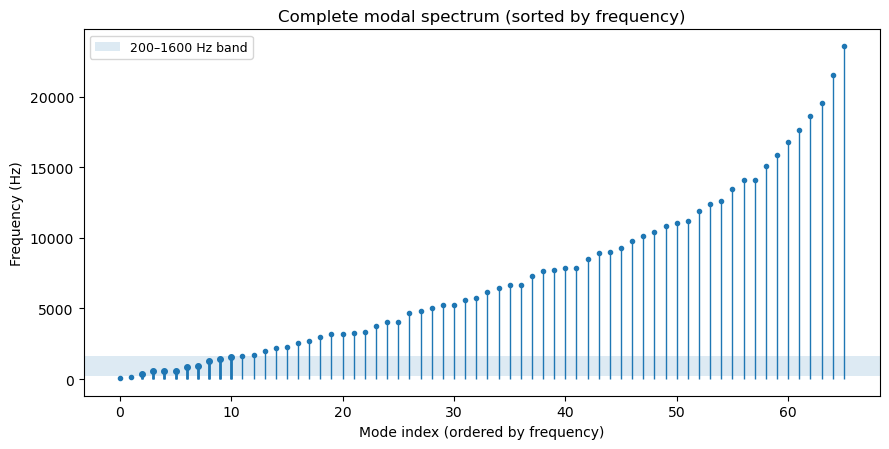

Saved: modal_spectrum_stems_EDIT3.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Collect and sort all positive frequencies
# ----------------------------
modes = []
freqs = []

for m in range(len(fVal)):
    for n in range(len(fVal[m])):
        f = float(fVal[m][n])
        if f > 0:
            modes.append((m, n))
            freqs.append(f)

freqs = np.array(freqs)
order = np.argsort(freqs)
freqs_sorted = freqs[order]
modes_sorted = [modes[i] for i in order]

k = np.arange(len(freqs_sorted))

# ----------------------------
# Optional: highlight measurement band
# ----------------------------
fmin_band, fmax_band = 200.0, 1600.0
in_band = (freqs_sorted >= fmin_band) & (freqs_sorted <= fmax_band)

# ----------------------------
# Plot stems
# ----------------------------
plt.figure(figsize=(9.0, 4.6))

# All modes
markerline, stemlines, baseline = plt.stem(k, freqs_sorted, basefmt=" ")
plt.setp(markerline, markersize=3)
plt.setp(stemlines, linewidth=1)

# Highlight band modes (overlay as thicker stems)
k_band = k[in_band]
f_band = freqs_sorted[in_band]
if len(k_band) > 0:
    markerline2, stemlines2, baseline2 = plt.stem(k_band, f_band, basefmt=" ")
    plt.setp(markerline2, markersize=4)
    plt.setp(stemlines2, linewidth=2)

plt.axhspan(fmin_band, fmax_band, alpha=0.15, label=f"{fmin_band:.0f}–{fmax_band:.0f} Hz band")

plt.title("Complete modal spectrum (sorted by frequency)")
plt.xlabel("Mode index (ordered by frequency)")
plt.ylabel("Frequency (Hz)")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()

plt.savefig("modal_spectrum_stems_EDIT3.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: modal_spectrum_stems_EDIT3.png")
